In [7]:
library(sf) #uso de información vectorial
library(terra) #uso de información raster
library(leaflet)
library(leafem)

In [2]:
dir_r <- "../02PeligroSubsidencia/subsidencia"
archivo_r <- "TorreonSenDT12_2014_2023_geoVelocity.tiff"
dir_data_r <- file.path(dir_r, archivo_r)

In [3]:
vul_coa <- st_read("../03VulnerabilidadSocial/resultados/Vulnerabilidad_Coa.shp")
vul_dur <- st_read("../03VulnerabilidadSocial/resultados/Vulnerabilidad_Dur.shp")

Reading layer `Vulnerabilidad_Coa' from data source 
  `/home/dan/Documentos/Documentacion_tesis/03VulnerabilidadSocial/resultados/Vulnerabilidad_Coa.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1882 features and 248 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -103.8035 ymin: 25.26309 xmax: -99.86494 ymax: 29.35575
Geodetic CRS:  +proj=longlat +datum=WGS84 +no_defs
Reading layer `Vulnerabilidad_Dur' from data source 
  `/home/dan/Documentos/Documentacion_tesis/03VulnerabilidadSocial/resultados/Vulnerabilidad_Dur.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1889 features and 248 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -106.972 ymin: 23.46332 xmax: -102.7688 ymax: 26.53841
Geodetic CRS:  +proj=longlat +datum=WGS84 +no_defs


Parte raster

In [4]:
vel_sub <- rast(dir_data_r)
ext<-c(-103.7,-102.45,25.2,26.1)
vel_sub <- crop(vel_sub, ext, snap= "near")
cort_sub <- -0.01
sub_des <- vel_sub <= cort_sub
area_sub <- as.polygons(sub_des) 
area_sub <- st_as_sf(area_sub) 
vel_sub_clas <- mask(vel_sub, area_sub[2,], updatevalue=NA)

Parte shape

In [5]:
Laguna_coa <- vul_coa[vul_coa$NOM_MUN %in% c("Torreón","Francisco I. Madero","Matamoros"),]
Laguna_dur <- vul_dur[vul_dur$NOM_MUN %in% c("Lerdo","Gómez Palacio"),]
la_laguna <- rbind(Laguna_coa, Laguna_dur)

## Peligro por Subsidencia y Vulnerabilidad Socioeconómica

Zona metropolitana La Laguna, Durango y Coahuila, México

Warning message in colors(.):
“Some values were outside the color scale and will be treated as NA”


HTML widgets cannot be represented in plain text (need html)
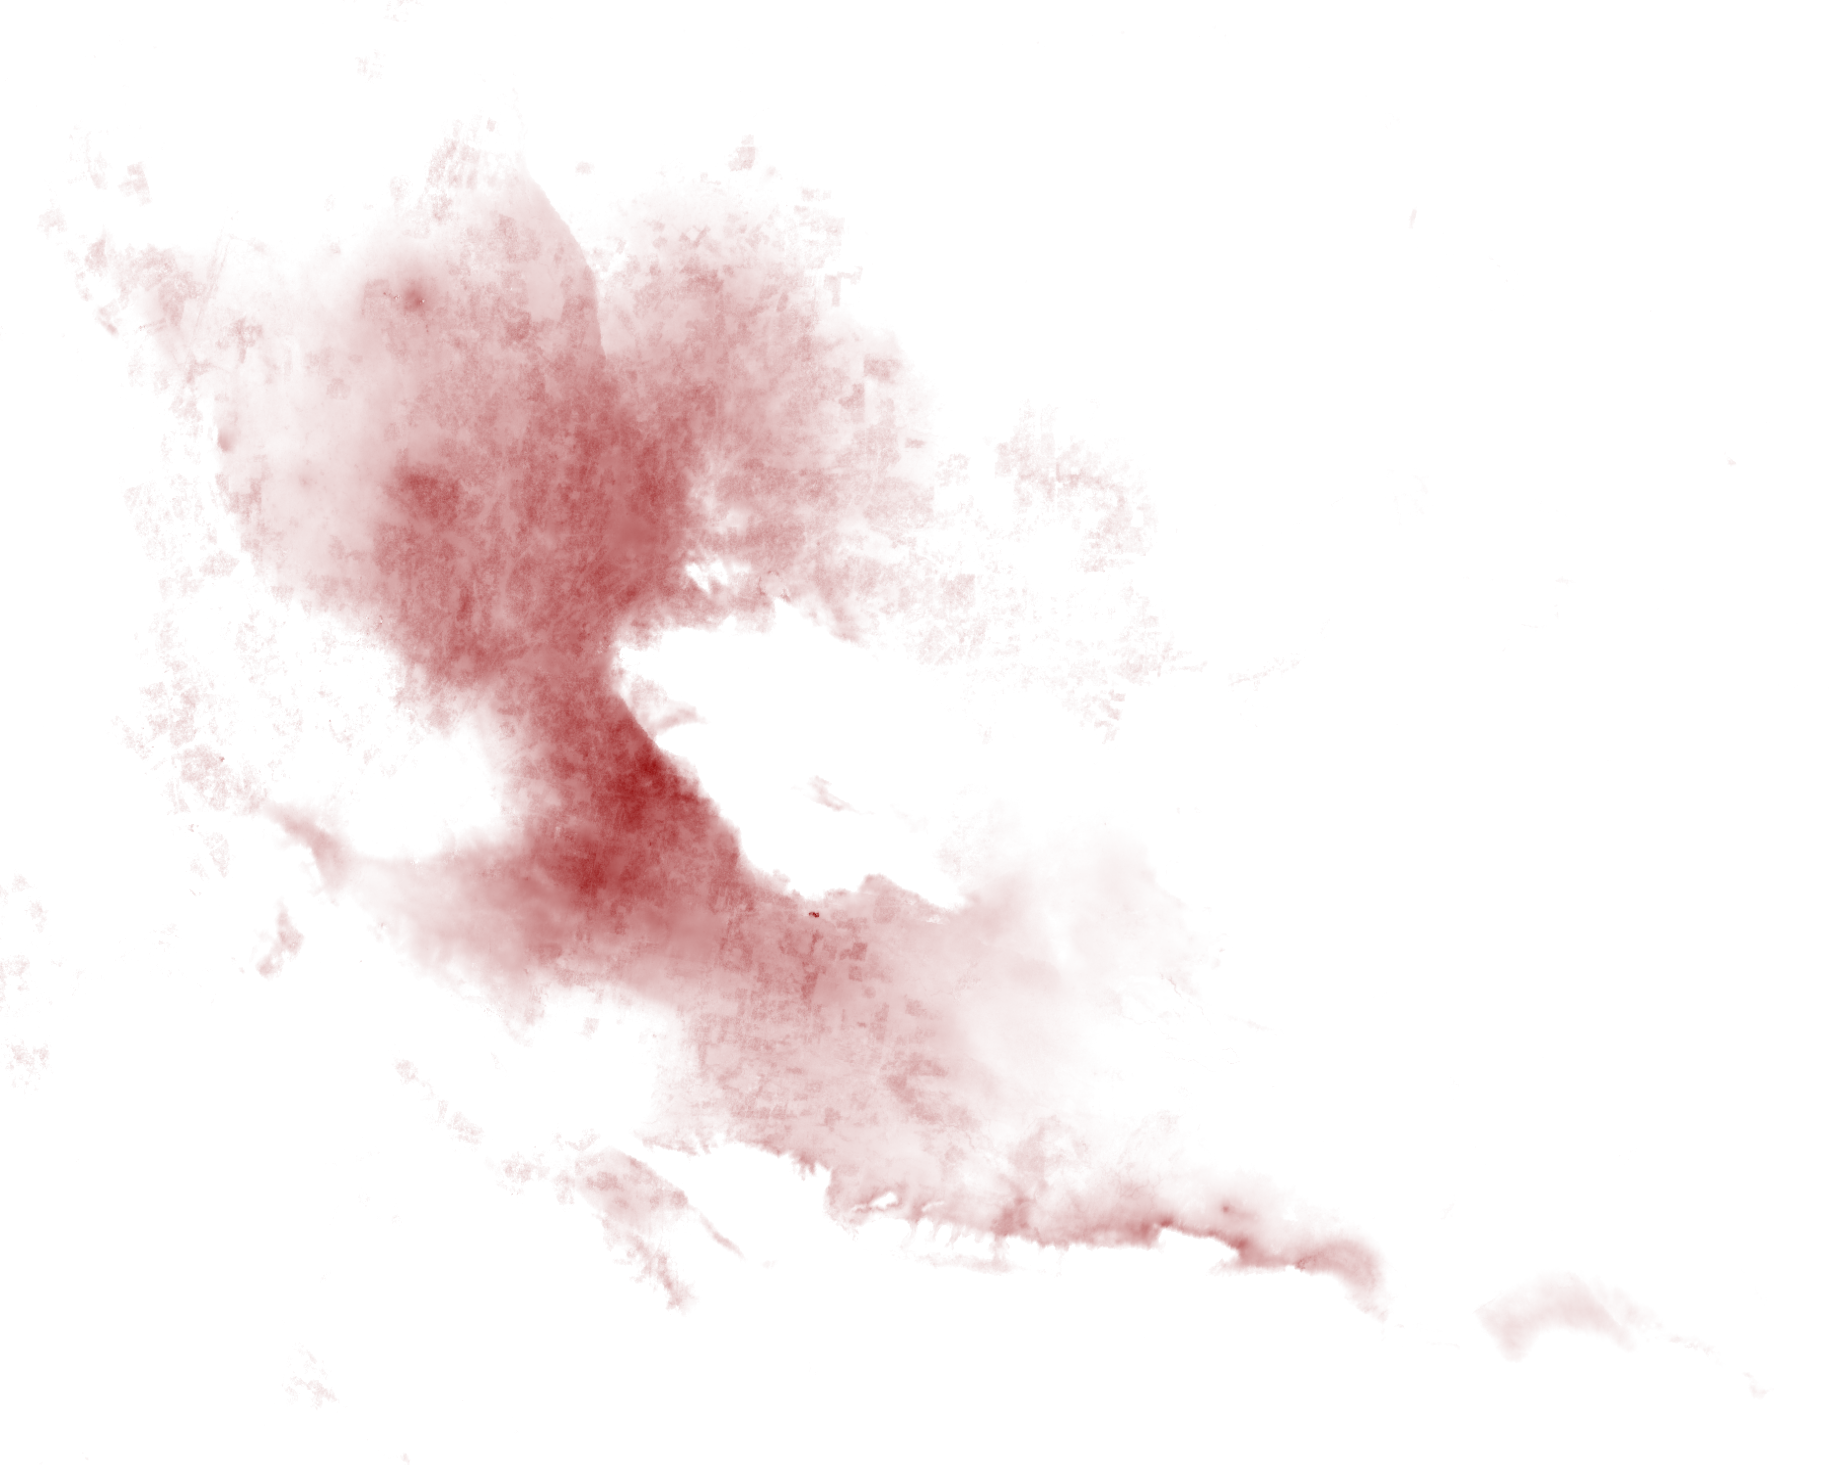

In [13]:
# Coordenadas del centro de la zona de interés
latitud <- 25.542485
longitud <- -103.396506
zoom <- 11  # Nivel de zoom deseado

# Definir las etiquetas cualitativas para el shapefile
labels <- c("Muy Baja", "Baja", "Moderada", "Alta", "Muy Alta")

# Definir colores manualmente en la escala RdYlGn para el shapefile
colores <- c("1" = "#1a9850",  # Verde fuerte
             "2" = "#91cf60",  # Verde claro
             "3" = "#ffffbf",  # Amarillo
             "4" = "#fc8d59",  # Naranja
             "5" = "#d73027")  # Rojo fuerte

# Crear una paleta de colores basada en los valores de NUM_VST (shapefile)
pal_shape <- colorFactor(palette = colores, domain = la_laguna$NUM_VST)

# Crear una paleta de colores para el raster (subsidencia)
pal_raster <- colorNumeric(palette = colorRamp(c("darkred", "white")), 
                           domain = values(vel_sub_clas), 
                           na.color = "transparent")

# Crear el mapa combinado
mapa <- leaflet() %>%
  addProviderTiles("OpenStreetMap") %>%  # Capa base
  # Capa del shapefile (vulnerabilidad)
  addPolygons(
    data = la_laguna,
    fillColor = ~pal_shape(NUM_VST),  # Usar NUM_VST para asignar colores
    weight = 1,
    opacity = 1,
    color = "black",
    dashArray = "4",
    fillOpacity = 0.6,
    highlightOptions = highlightOptions(
      weight = 5,
      color = "#666",
      dashArray = "",
      fillOpacity = 0.7,
      bringToFront = TRUE
    ),
    popup = ~paste("AGEB: ", CVE_AGE, "<br>", 
                   "Municipio: ", NOM_MUN, "<br>", 
                   "Población: ", POBTOT, " habitantes", "<br>", 
                   "Área:", round(are_km2, 3), "km²"),
    label = ~NOM_VST,
    labelOptions = labelOptions(
      style = list("font-weight" = "normal", padding = "2px 6px"),
      textsize = "12px",
      direction = "auto"
    ),
    group = "Vulnerabilidad"  # Nombre del grupo para el control de capas
  ) %>%
  # Leyenda para el shapefile
  addLegend(
    colors = colores,  # Colores definidos manualmente
    labels = labels,   # Etiquetas cualitativas
    title = "Vulnerabilidad",
    opacity = 1,
    position = "bottomright",
    group = "Vulnerabilidad"  # Asociar leyenda al grupo
  ) %>%
  # Capa del raster (subsidencia)
  addRasterImage(
    vel_sub, 
    colors = pal_raster, 
    project = TRUE, 
    group = "Subsidencia",  # Nombre del grupo para el control de capas
    opacity = 0.6
  ) %>%
  # Leyenda para el raster
  addLegend(
    pal = pal_raster, 
    values = values(vel_sub_clas), 
    title = "Subsidencia (m/año)", 
    position = "bottomleft",
    group = "Subsidencia"  # Asociar leyenda al grupo
  ) %>%
  # Control de capas
  addLayersControl(
    overlayGroups = c("Vulnerabilidad", "Subsidencia"),  # Grupos de capas
    options = layersControlOptions(collapsed = TRUE)  # Mostrar controles expandidos
  ) %>%
  # Coordenadas del mouse
  addMouseCoordinates() %>%
  # Vista inicial
  setView(lng = longitud, lat = latitud, zoom = zoom) 

# Mostrar el mapa
mapa

```{note}
Para mostrar información hacer click en los polígonos de vulnerabilidad Socioeconómica
```